# Heart Disease Classification Pipeline: Synthetic Data Generation & Explainable AI

#### Technical Artefact - Final Year Project

## Overview:
In this notebook, we will look at the implementation of a complete binary classification pipeline for heart disease. In addition to the standard process of training various machine learning models to select the best one, we will see how the use of synthetic data generated using GPT-GANs can help address various issues associated with clinical data collection (such as privacy concerns, as well as the scarcity of such data, given how difficult it is to obtain).

We will also analyse how models make decisions using techniques such as feature importance and SHAP, gaining an understanding of how a model makes a particular choice. Furthermore, we will examine the social impact that a machine learning model can have by conducting a fairness analysis on both the data and the models.

### Objectives:

1. Data Acquisition: loading the clinical heart disease dataset.
2. Synthetic Data Generation: creation of a synthetic dataset of 10,000 records using CTGAN for high-fidelity tabular data.
3. Comparative EDA: statistical and visual analysis of the distribution of the synthetic dataset versus the real dataset.
4. ML Pipeline (Preprocessing and Training): a machine learning pipeline using the sklearn pipeline, ranging from data pre-processing to training different classifiers using synthetic data exclusively.
5. Model Evaluation: testing different classifiers on the unseen real-world dataset following the Train Synthetic, Test Real approach.
6. Explainability: feature importance analysis and SHAP to understand the decisions made by complex models.
7. Fairness Analysis: to investigate the social impact that the model or data has on specific subgroups (e.g. gender, age, etc.).


## Basic setup:

In [ ]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# add the root folder to the python path 
# (this fixes problems with importing modules inside the notebook)
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

# data manipulation libraries
import pandas as pd
import numpy as np

# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
# custom EDA modules
from src.eda_utils import plot_hist, plot_bar, plot_box, calculate_statistics
from src.eda_utils import frequency_table, statistical_tests, numeric_biv_analysis
from src.eda_utils import qualitative_association, plot_corr_matrix

# custom data loader module
from src.data_loader import load_data

# custom synthetic generation module
from src.synthesizer import generate_syn_df, diagnostic_report, quality_report, get_column_plot

# model development and evalation libraries and modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from src.models import evaluate_synthetic_quality



We prepare the data we are going to use, both the real and the synthetic data.

In [27]:
# load original dataset 
df = load_data()
print(df.head())

# generate synthetic data
syn_df = generate_syn_df(df, n_epochs=300)
print(syn_df.head())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
Loading existing model: C:\Users\Riccardo\Desktop\computer-science-project\models\ctgan_300_epochs.pkl
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   56   M           AS

## Dataset Overview

**Attribute information reported from the dataset Kaggle webpage** :

1. Age: age of the patient (years)
2. Sex: sex of the patient [M: Male, F: Female]
3. ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
4. RestingBP: resting blood pressure [mm Hg]
5. Cholesterol: serum cholesterol [mm/dl]
6. FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
7. RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
8. MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
9. ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
10. Oldpeak: oldpeak = ST [Numeric value measured in depression]
11. ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
12. HeartDisease: output class [1: heart disease, 0: Normal]

In [28]:
print(df.info())

print(syn_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  

As we can see, the first dataset consists of a total of 918 rows, with each row representing a patient who may or may not have heart disease. The target variable “HeartDisease” is a binary variable, where 0 indicates the absence of heart disease and 1 indicates the presence of heart disease.

We also note that there do not appear to be any missing values in the dataset; however, we must investigate whether there are any duplicate values, as these could pose problems for the future training of a predictive model.

The synthetic dataset, on the other hand, has 10,000 rows, and from this initial analysis, it too appears to have no missing values.

In [29]:
# check duplicated rows
print(df.duplicated().sum())

# check duplicated rows on syn_df
print(df.duplicated().sum())

0
0


From the results obtained, we can see that there are no duplicate rows in either the original dataset or the synthetic dataset. These results are particularly encouraging with regard to the synthetic dataset, as it means that the CTGAN model is not simply copying data from the original dataset, but is attempting to capture the relationships between the data in order to generate new data.

## EDA

### Univariate Analysis

#### Numerical Features

In [30]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [31]:
syn_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,44.643200,123.605700,285.101800,0.258000,110.936200,1.342520,0.561300
std,11.094846,19.397976,100.184239,0.437556,31.652951,1.529404,0.496253
min,29.000000,92.000000,0.000000,0.000000,63.000000,-2.600000,0.000000
25%,36.000000,109.000000,247.000000,0.000000,86.000000,0.200000,0.000000
50%,44.000000,128.000000,308.000000,0.000000,110.000000,0.300000,1.000000
75%,52.000000,136.000000,350.000000,1.000000,134.000000,2.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,192.000000,5.600000,1.000000


We can see that the range of values is preserved in the synthetic dataset, and we also observe a similar distribution for some binary variables such as FastingBS and the HeartDisease target. Nevertheless, the descriptive statistics for continuous variables such as Age and Cholesterol are significantly higher, shifting the distribution towards higher values. From this, we can see how the generation of synthetic data shifts the distribution towards higher values and introduces greater variability.

In addition, we can see that some continuous variables exhibit outliers in both the real dataset and the synthetic dataset. For example, the RestingBP variable has a minimum value of 0 in the real dataset, which is impossible for a living patient; this therefore indicates either a data recording error or an error in coding missing values as 0. We observe the same behaviour for the Cholesterol variable in both the real and synthetic datasets.

In [32]:
quantitative_features = df.drop(['HeartDisease', 'FastingBS'], axis=1).select_dtypes(include=['int64', 'float64']).columns
calculate_statistics(df[quantitative_features])

,Mean,Median,Mode,Min,Max,Variance,Standard Deviation,Range,Skewness,Kurtosis
Age,53.51,54.00,54.00,28.00,77.00,88.97,9.43,49.00,-0.20,-0.39
RestingBP,132.40,130.00,120.00,0.00,200.00,342.77,18.51,200.00,0.18,3.27
Cholesterol,198.80,223.00,0.00,0.00,603.00,11964.89,109.38,603.00,-0.61,0.12
MaxHR,136.81,138.00,150.00,60.00,202.00,648.23,25.46,142.00,-0.14,-0.45
Oldpeak,0.89,0.60,0.00,-2.60,6.20,1.14,1.07,8.80,1.02,1.20


In [33]:
calculate_statistics(syn_df[quantitative_features])

,Mean,Median,Mode,Min,Max,Variance,Standard Deviation,Range,Skewness,Kurtosis
Age,44.64,44.00,29.00,29.00,77.00,123.10,11.09,48.00,0.44,-0.37
RestingBP,123.61,128.00,92.00,92.00,200.00,376.28,19.40,108.00,0.13,0.07
Cholesterol,285.10,308.00,0.00,0.00,603.00,10036.88,100.18,603.00,-1.09,1.21
MaxHR,110.94,110.00,63.00,63.00,192.00,1001.91,31.65,129.00,0.26,-0.74
Oldpeak,1.34,0.30,0.30,-2.60,5.60,2.34,1.53,8.20,1.06,0.20


Let us now look in more detail at the descriptive statistics for continuous numerical variables.

The descriptive statistics of the continuous variables show that the real dataset presents generally moderate variability and relatively symmetric distributions, as the mean and median values are often close. Age and MaxHR exhibit near-symmetric distributions with only slight skewness, indicating balanced variability around the central tendency. In contrast, some variables show notable anomalies, particularly RestingBP and Cholesterol, where the minimum value of 0 suggests the presence of unrealistic measurements or potential data entry issues, which also contributes to higher variance and dispersion.

When comparing the real and synthetic datasets, the synthetic data generally reproduce the overall distributional patterns of the original variables, maintaining similar levels of variability and skewness. However, some differences emerge in the central tendency and range of certain variables, particularly Age and RestingBP. Notably, the synthetic dataset does not replicate the extreme minimum values observed in the real dataset, suggesting that the generation process may have smoothed or filtered out some of the anomalies present in the original data.

#### Categorical Features

In [34]:
qualitative_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope", "HeartDisease"]

df.describe(include='O')

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [35]:
syn_df.describe(include='O')

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,10000,10000,10000,10000,10000
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,7659,4973,5549,5757,5045


In [36]:
# for each qualitative col we print the freq table
for col in qualitative_cols:
    print("====== REAL ======")
    # frequency table
    freq_table = frequency_table(df=df, column=col)
    print(freq_table)

    # synthetic
    print("====== SYNTHETIC ======")
    syn_freq_table = frequency_table(df=syn_df, column=col)
    print(syn_freq_table)

    print("-"*50)

====== REAL ======
     ABS Freq  REL Freq (%)
Sex                        
M         725         78.98
F         193         21.02
====== SYNTHETIC ======
     ABS Freq  REL Freq (%)
Sex                        
M        7659         76.59
F        2341         23.41
--------------------------------------------------
====== REAL ======
               ABS Freq  REL Freq (%)
ChestPainType                        
ASY                 496         54.03
NAP                 203         22.11
ATA                 173         18.85
TA                   46          5.01
====== SYNTHETIC ======
               ABS Freq  REL Freq (%)
ChestPainType                        
ASY                4973         49.73
NAP                2346         23.46
ATA                1837         18.37
TA                  844          8.44
--------------------------------------------------
====== REAL ======
           ABS Freq  REL Freq (%)
FastingBS                        
0               704         76.69
1          

From the frequency tables of the categorical variables, it can be observed that the synthetic dataset largely preserves the distribution of the real dataset. The relative frequencies across most variables remain very similar, indicating that the synthetic data generation process successfully reproduces the overall structure of the categorical features. The target variable 'HeartDisease' does not appear to be strongly imbalanced in either dataset, with relatively comparable proportions between the two classes.

One notable aspect concerns the variable 'Sex', which is clearly imbalanced in both datasets, with a substantially higher proportion of male patients compared to female patients. This imbalance is consistent between the real and synthetic data and will be further investigated in the fairness analysis to assess whether it may influence the model’s behavior.

### Data Visualization

#### Distribution of Numerical Features

====== REAL ======


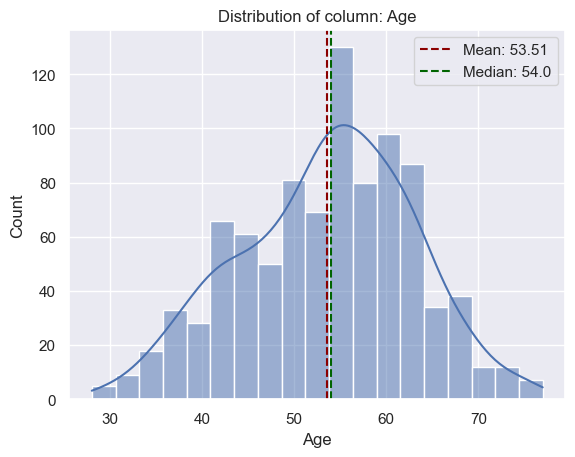

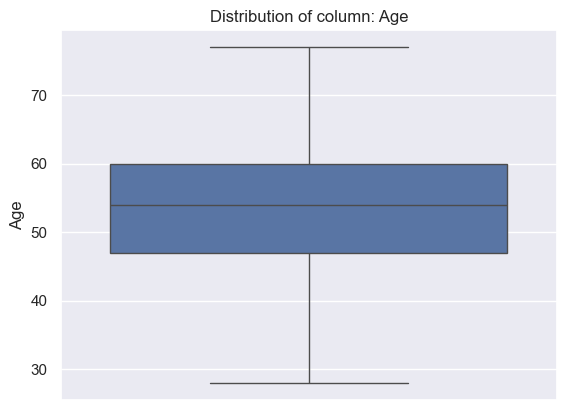

====== SYNTHETIC ======


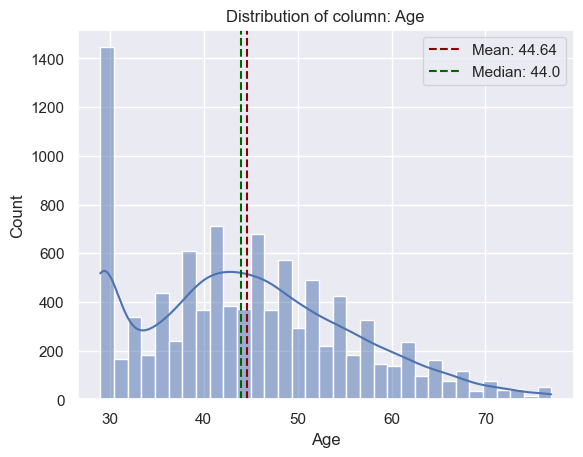

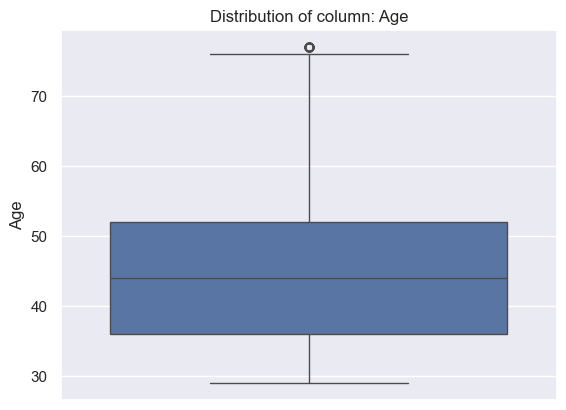

====== REAL ======


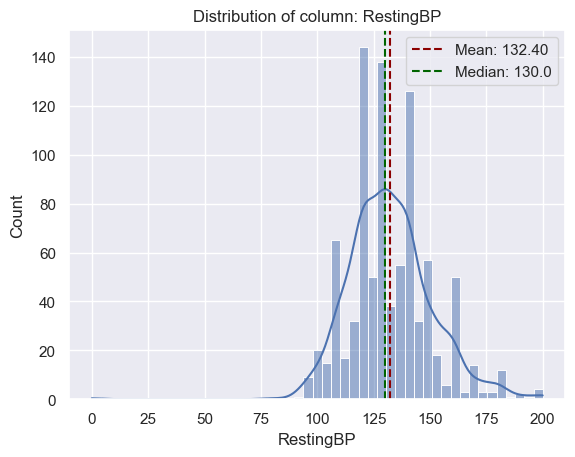

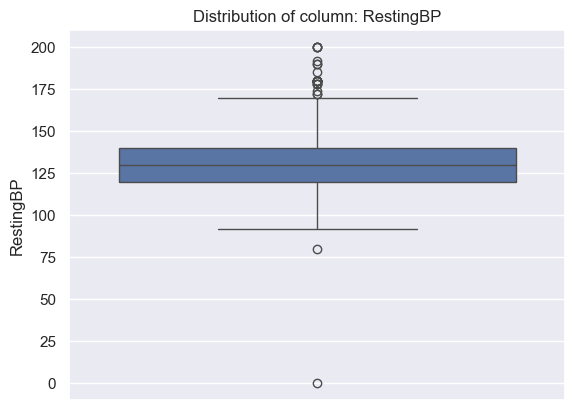

====== SYNTHETIC ======


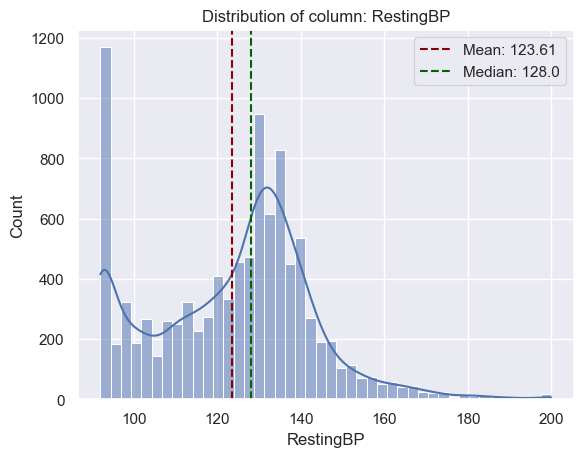

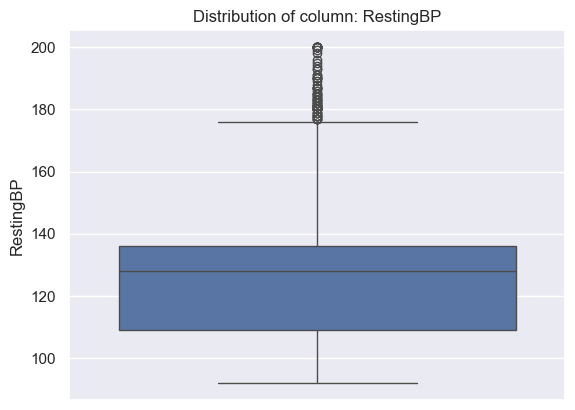

====== REAL ======


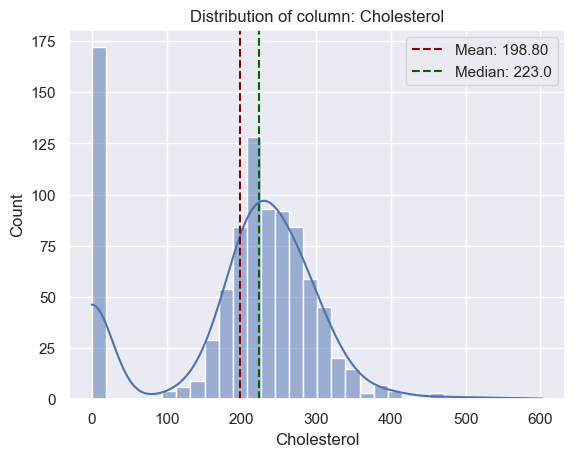

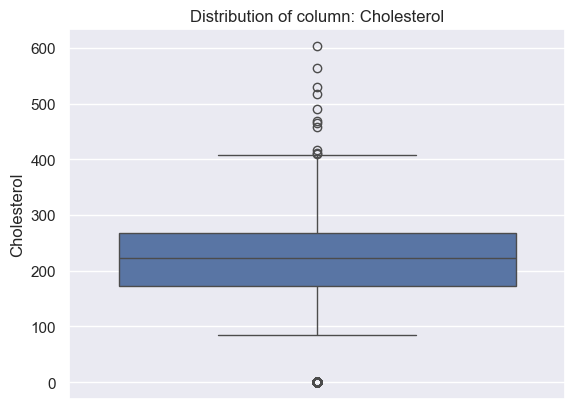

====== SYNTHETIC ======


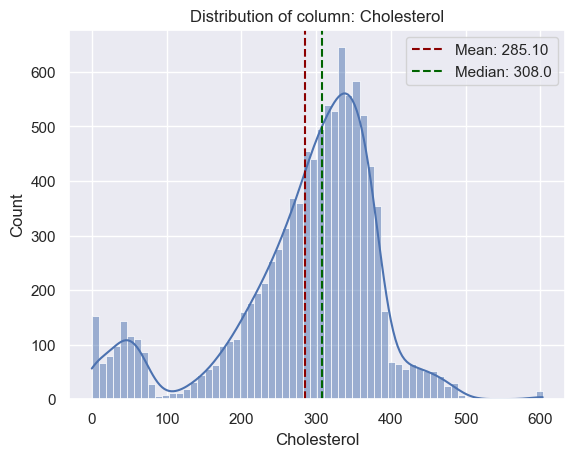

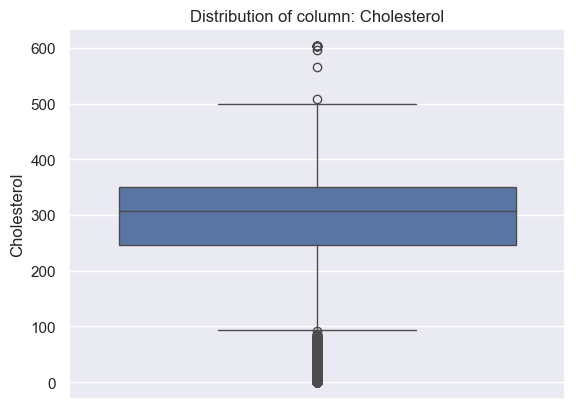

====== REAL ======


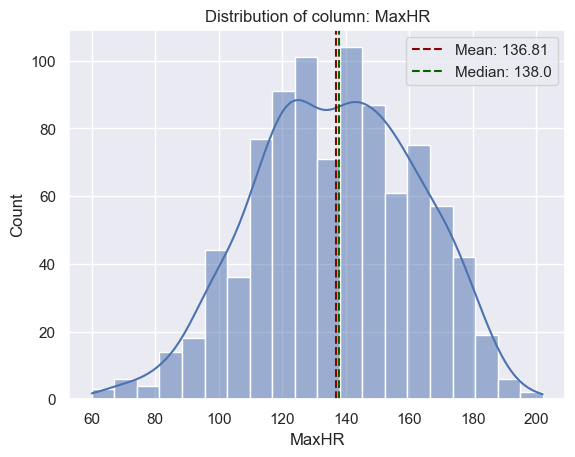

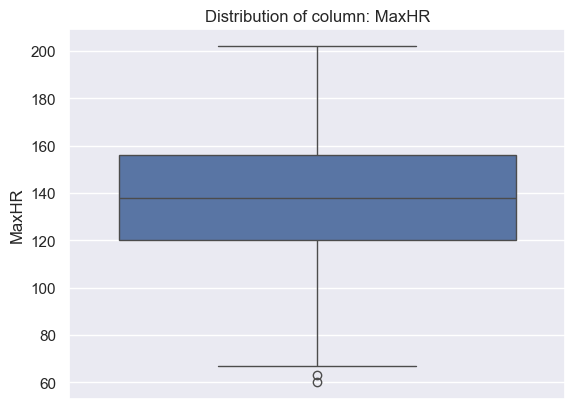

====== SYNTHETIC ======


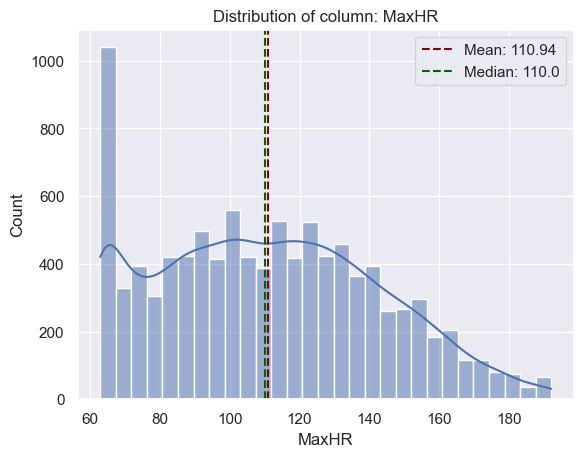

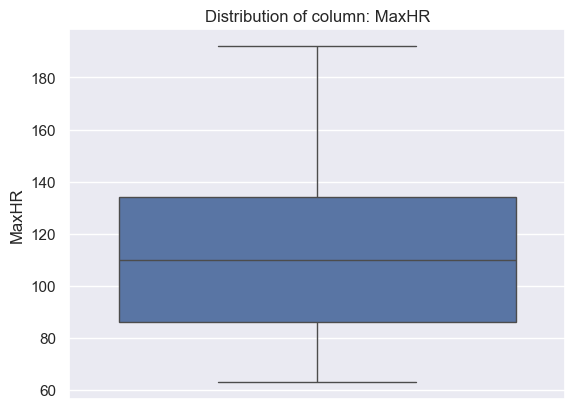

====== REAL ======


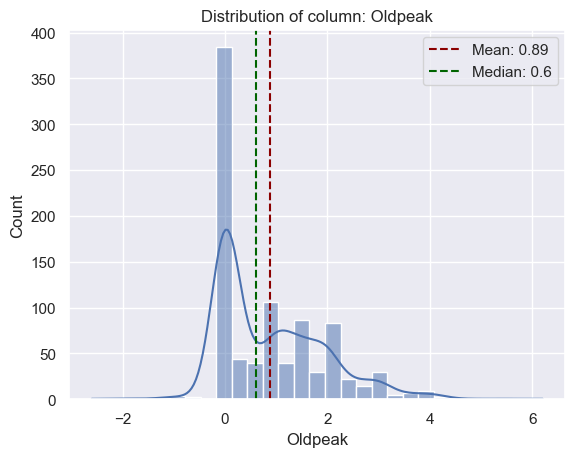

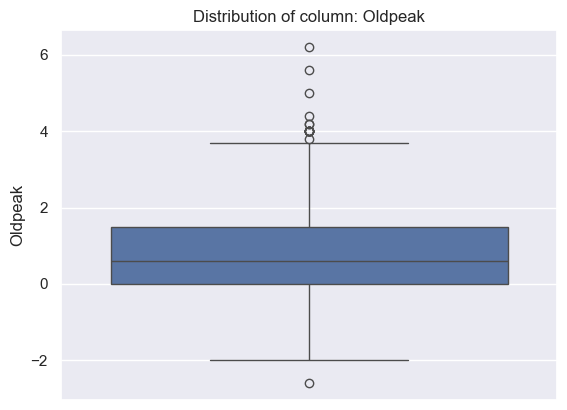

====== SYNTHETIC ======


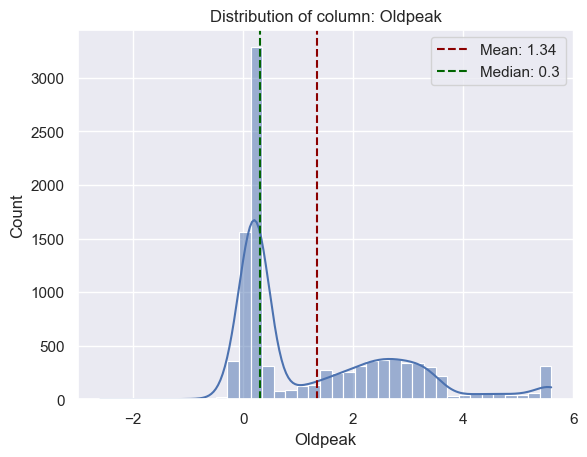

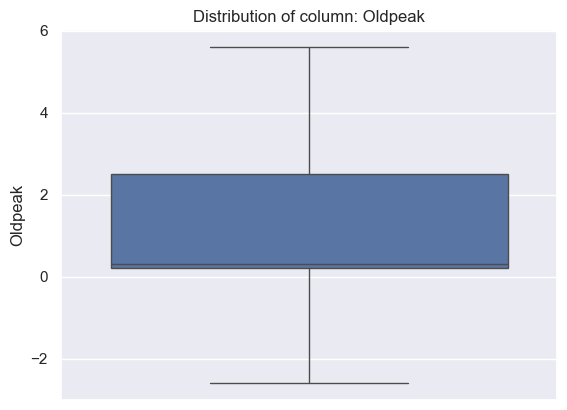

In [37]:
# for each numeric column
for col in quantitative_features:
    print("====== REAL ======")
    plot_hist(df=df, column=col)
    plt.show()
    plot_box(df=df, column1=col)
    plt.show()

    # synthetic
    print("====== SYNTHETIC ======")
    plot_hist(syn_df, column=col)
    plt.show()
    plot_box(df=syn_df, column1=col)
    plt.show()

By examining the histograms and box plots, we gain further insight into the distribution of the data, enabling us to compare the real dataset with the synthetic one. Generally speaking, the distribution of the synthetic data seeks to replicate patterns similar to those observed in the original dataset, suggesting that the data generation process has largely succeeded in capturing the statistical relationships between the variables.

However, substantial differences emerge in the extreme values of the synthetic distribution. In many cases, we see that the synthetic data are much more scattered than the real observations, which is consistent with the variance and standard deviation values observed previously. Furthermore, for some variables, we note that the minimum value becomes the most frequent in the distribution, shifting it and altering its shape compared to the original distribution.

The box plots also highlight the presence of new outliers generated by the synthetic data. These discrepancies show that although the synthetic data are capable of preserving many of the original properties of the data, they do not perfectly reproduce all the hidden aspects of the distributions.

#### Distribution of Categorical Features

====== REAL ======


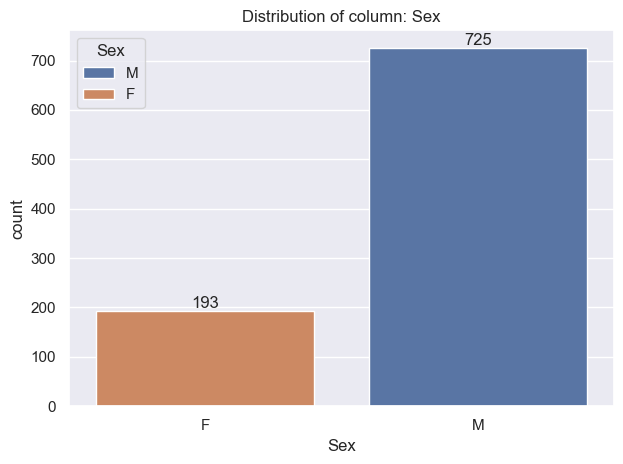

====== SYNTHETIC ======


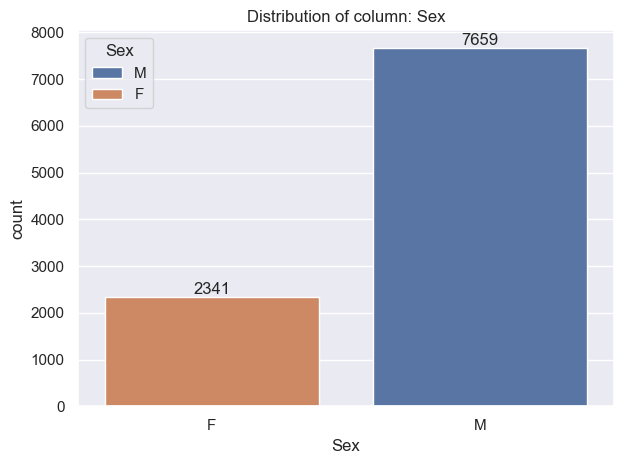

====== REAL ======


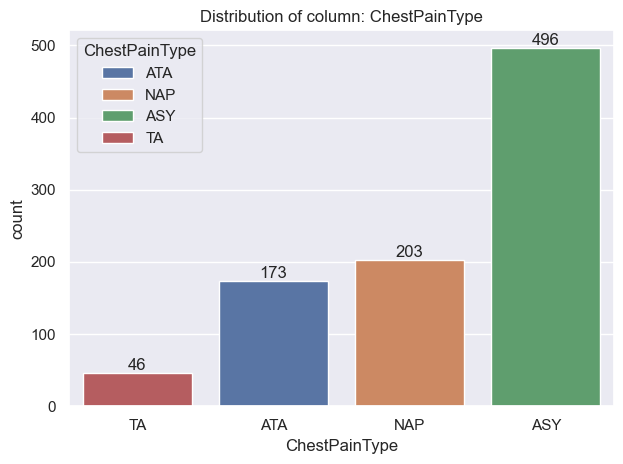

====== SYNTHETIC ======


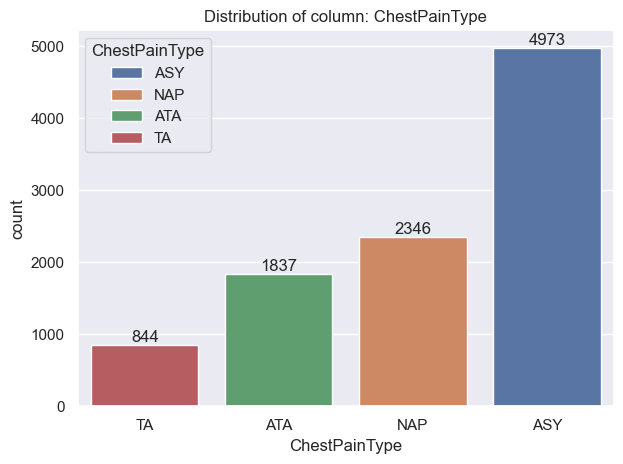

====== REAL ======


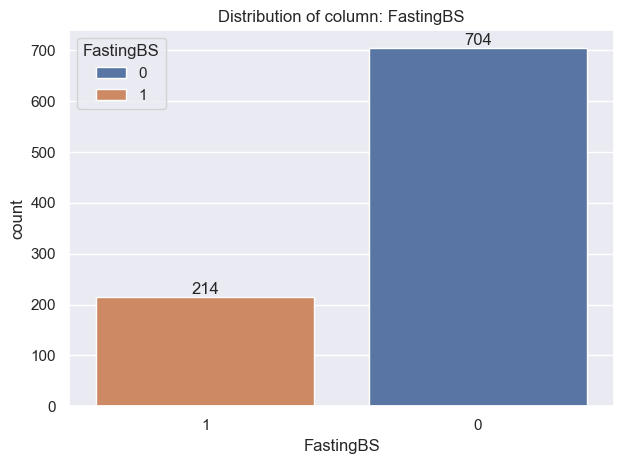

====== SYNTHETIC ======


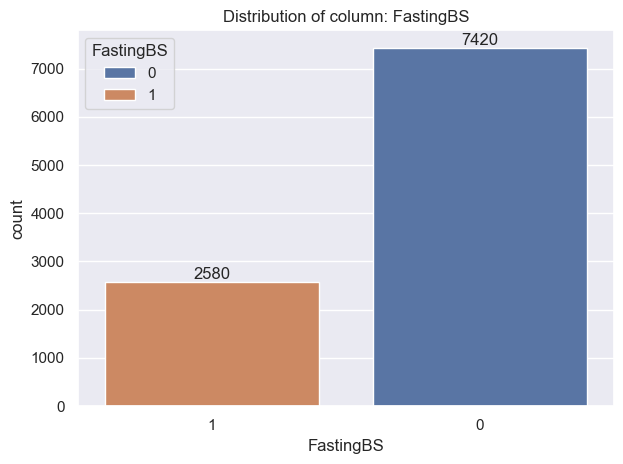

====== REAL ======


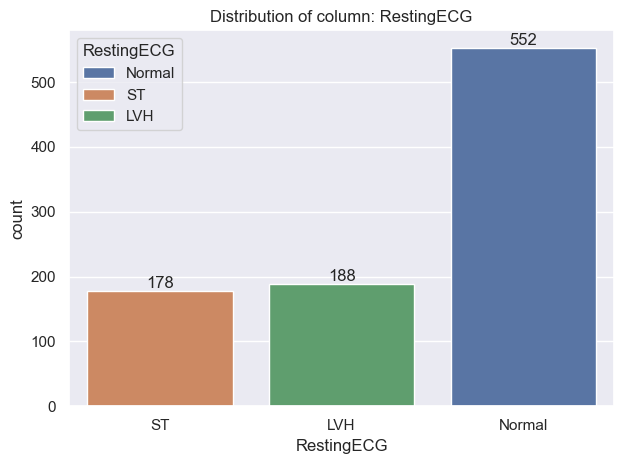

====== SYNTHETIC ======


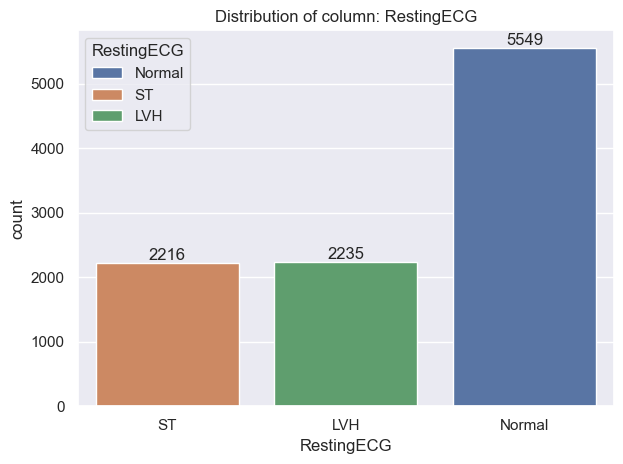

====== REAL ======


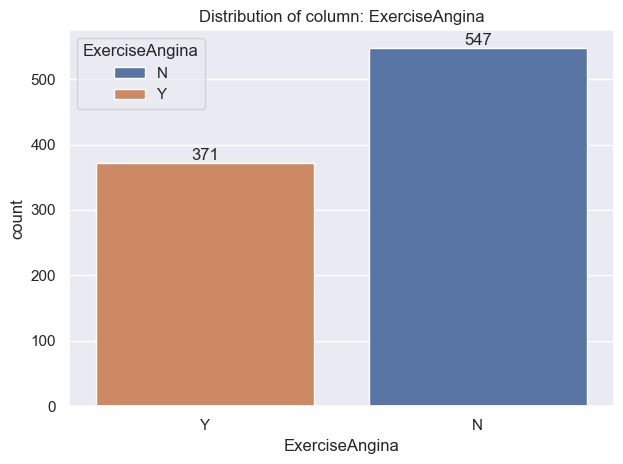

====== SYNTHETIC ======


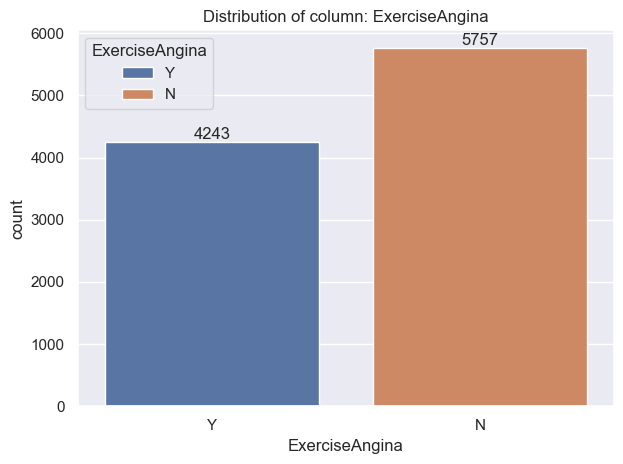

====== REAL ======


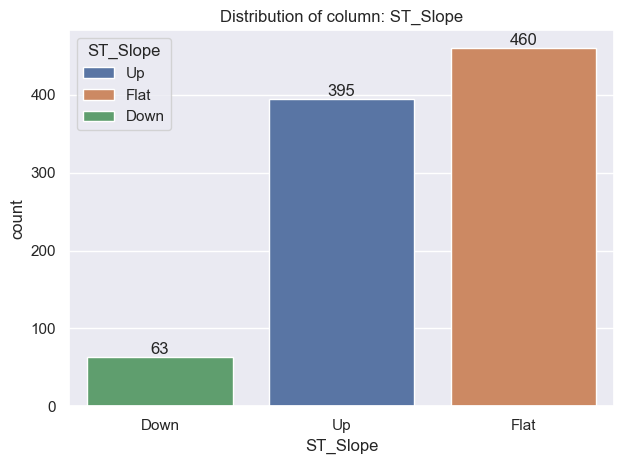

====== SYNTHETIC ======


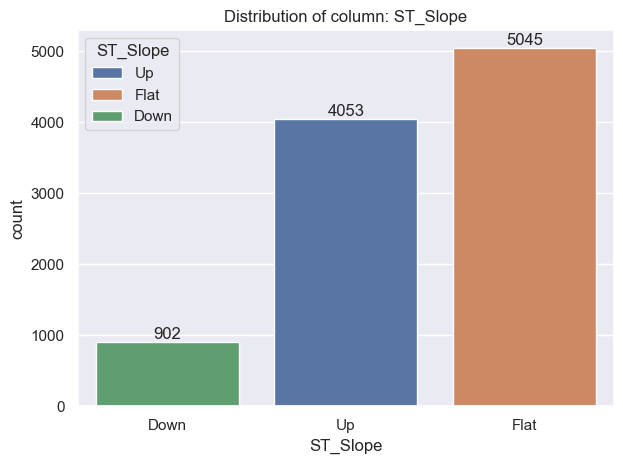

====== REAL ======


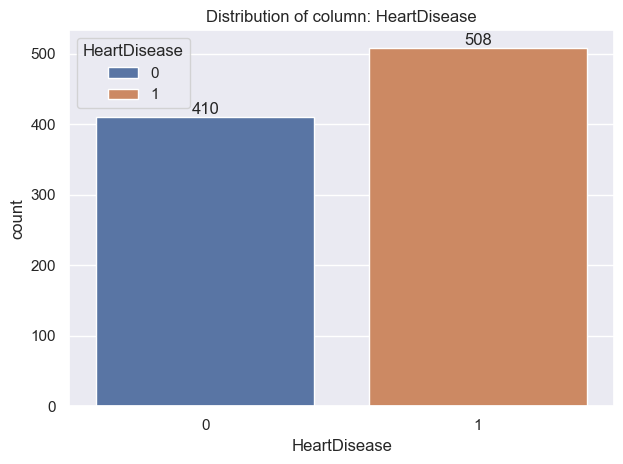

====== SYNTHETIC ======


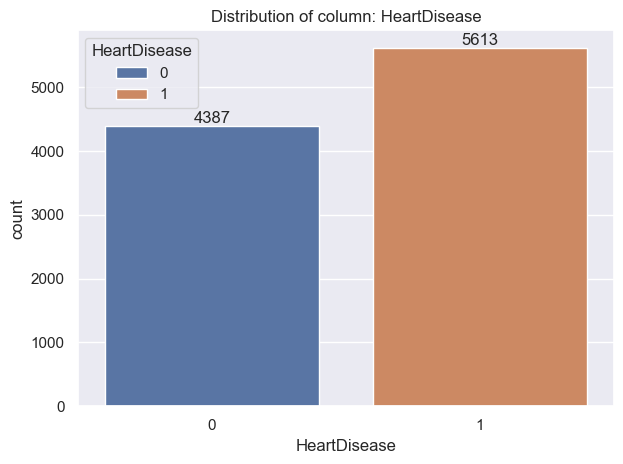

In [38]:
# for each categorical column
for col in qualitative_cols:
    # real
    print("====== REAL ======")
    plot_bar(df= df, column= col)
    plt.show()

    # synthetic
    print("====== SYNTHETIC ======")
    plot_bar(df= syn_df, column= col)
    plt.show()

From the graphical analysis of the categorical features, we can see visually what we analysed earlier using the frequency tables; we can confirm that the summary statistics have reproduced the original distribution of the data fairly accurately.

### Bivariate Analysis

#### Quantitative Features Vs Target

**Real dataset**

Distribution of Age per 'HeartDisease'
              count       mean       std   min   25%   50%   75%   max
HeartDisease                                                          
0             410.0  50.551220  9.444915  28.0  43.0  51.0  57.0  76.0
1             508.0  55.899606  8.727056  31.0  51.0  57.0  62.0  77.0

Statistical tests:
Shapiro test per Age (target = 0) ShapiroResult(statistic=np.float64(0.992864480021719), pvalue=np.float64(0.04834843555074684))
Shapirot test per Age (target = 1) ShapiroResult(statistic=np.float64(0.9851362527999588), pvalue=np.float64(4.691321923131884e-05))

Mann-Whitney U Test:
U-statistic: 69137.5000, p-value: 1.8057e-18

P-value T-test
6.348336655825792e-18


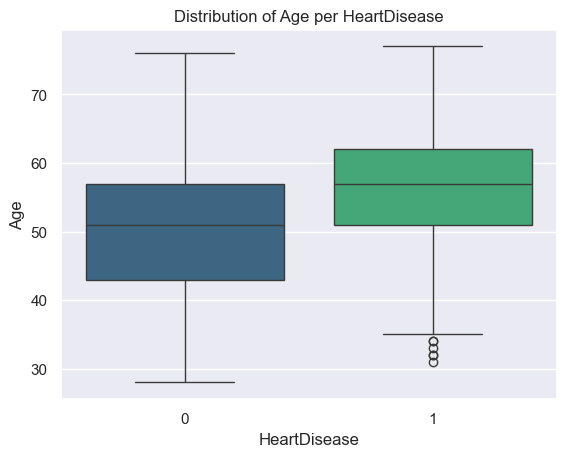

--------------------------------------------------
Distribution of RestingBP per 'HeartDisease'
              count        mean        std   min    25%    50%    75%    max
HeartDisease                                                                
0             410.0  130.180488  16.499585  80.0  120.0  130.0  140.0  190.0
1             508.0  134.185039  19.828685   0.0  120.0  132.0  145.0  200.0

Statistical tests:
Shapiro test per RestingBP (target = 0) ShapiroResult(statistic=np.float64(0.9665626027005608), pvalue=np.float64(4.632623852746703e-08))
Shapirot test per RestingBP (target = 1) ShapiroResult(statistic=np.float64(0.9531951430130495), pvalue=np.float64(1.3201708844084489e-11))

Mann-Whitney U Test:
U-statistic: 90420.0000, p-value: 5.6481e-04

P-value T-test
0.0008732264734356638


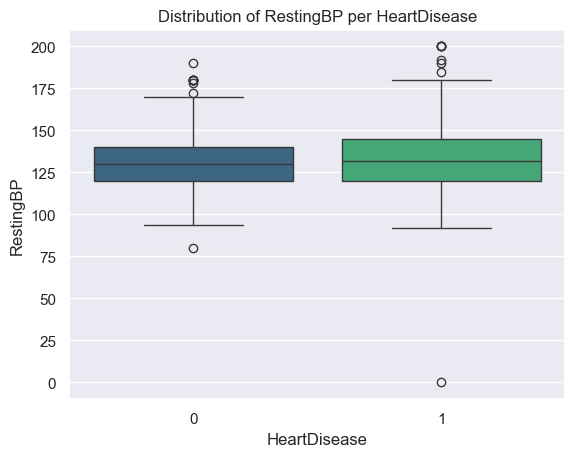

--------------------------------------------------
Distribution of Cholesterol per 'HeartDisease'
              count        mean         std  min     25%    50%     75%    max
HeartDisease                                                                  
0             410.0  227.121951   74.634659  0.0  197.25  227.0  266.75  564.0
1             508.0  175.940945  126.391398  0.0    0.00  217.0  267.00  603.0

Statistical tests:
Shapiro test per Cholesterol (target = 0) ShapiroResult(statistic=np.float64(0.8931721739156645), pvalue=np.float64(2.5818736945874754e-16))
Shapirot test per Cholesterol (target = 1) ShapiroResult(statistic=np.float64(0.8585545030379402), pvalue=np.float64(5.511404609812113e-21))

Mann-Whitney U Test:
U-statistic: 121000.5000, p-value: 2.2803e-05

P-value T-test
6.481235871514514e-14


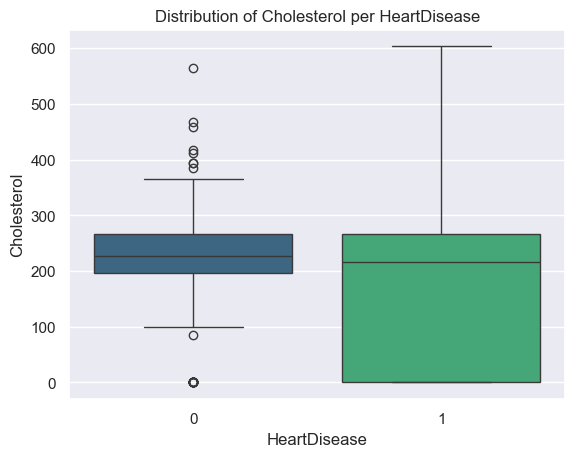

--------------------------------------------------
Distribution of MaxHR per 'HeartDisease'
              count        mean        std   min    25%    50%     75%    max
HeartDisease                                                                 
0             410.0  148.151220  23.288067  69.0  134.0  150.0  165.00  202.0
1             508.0  127.655512  23.386923  60.0  112.0  126.0  144.25  195.0

Statistical tests:
Shapiro test per MaxHR (target = 0) ShapiroResult(statistic=np.float64(0.9822157158677576), pvalue=np.float64(6.238449771115916e-05))
Shapirot test per MaxHR (target = 1) ShapiroResult(statistic=np.float64(0.9961303552653978), pvalue=np.float64(0.2518386164544654))

Mann-Whitney U Test:
U-statistic: 153089.5000, p-value: 1.5064e-34

P-value T-test
1.4306374887872695e-36


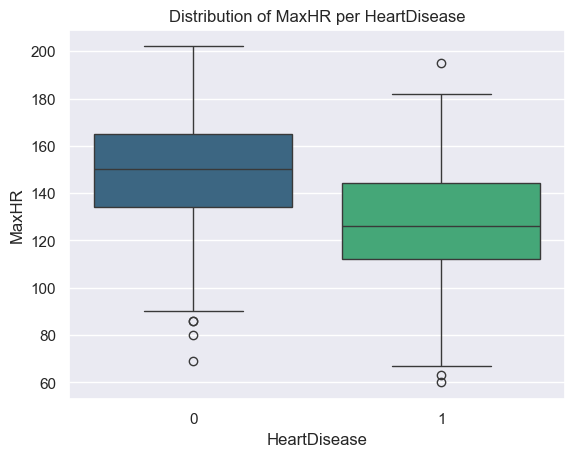

--------------------------------------------------
Distribution of Oldpeak per 'HeartDisease'
              count      mean       std  min  25%  50%  75%  max
HeartDisease                                                    
0             410.0  0.408049  0.699709 -1.1  0.0  0.0  0.6  4.2
1             508.0  1.274213  1.151872 -2.6  0.0  1.2  2.0  6.2

Statistical tests:
Shapiro test per Oldpeak (target = 0) ShapiroResult(statistic=np.float64(0.6836346545479408), pvalue=np.float64(5.437137558437059e-27))
Shapirot test per Oldpeak (target = 1) ShapiroResult(statistic=np.float64(0.9471447976884202), pvalue=np.float64(1.7282297268135758e-12))

Mann-Whitney U Test:
U-statistic: 55164.0000, p-value: 6.7678e-37

P-value T-test
1.9027223920937582e-40


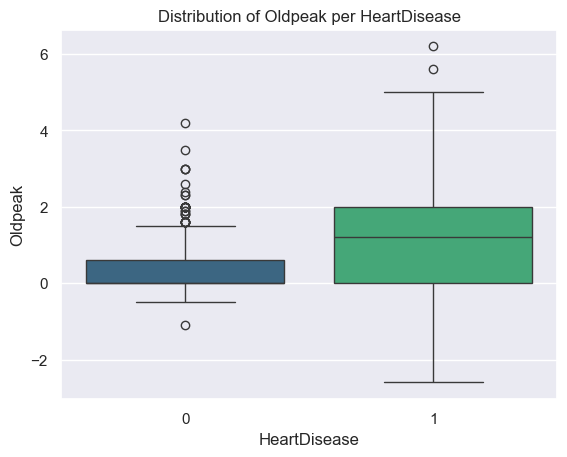

--------------------------------------------------


In [39]:
# real 
for col in quantitative_features:
    print(f"Distribution of {col} per 'HeartDisease'")
    numeric_biv_analysis(df=df, column=col)
    plt.show()
    print("-"*50)

**Synthetic dataset**

Distribution of Age per 'HeartDisease' (SYNTHETIC)
               count       mean        std   min   25%   50%   75%   max
HeartDisease                                                            
0             4387.0  44.390472  10.909361  29.0  36.0  44.0  51.0  77.0
1             5613.0  44.840727  11.234696  29.0  36.0  44.0  52.0  77.0

Statistical tests:
Shapiro test per Age (target = 0) ShapiroResult(statistic=np.float64(0.9611592385535138), pvalue=np.float64(9.306510382591466e-33))
Shapirot test per Age (target = 1) ShapiroResult(statistic=np.float64(0.9612536300927486), pvalue=np.float64(2.7228885465491118e-36))

Mann-Whitney U Test:
U-statistic: 12054025.0000, p-value: 7.1207e-02

P-value T-test
0.04326762999101406


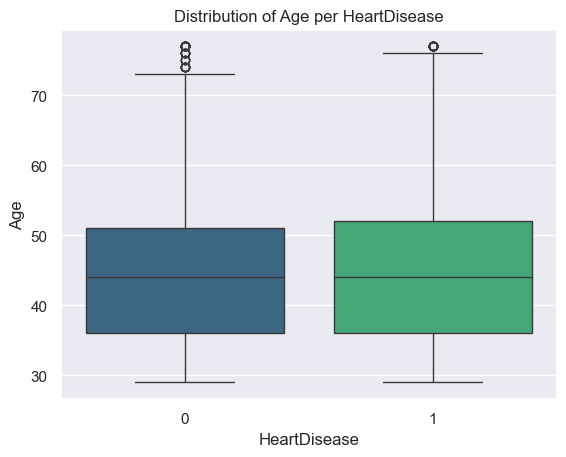

--------------------------------------------------
Distribution of RestingBP per 'HeartDisease' (SYNTHETIC)
               count        mean        std   min    25%    50%    75%    max
HeartDisease                                                                 
0             4387.0  123.207659  19.407866  92.0  108.5  127.0  136.0  200.0
1             5613.0  123.916800  19.386281  92.0  110.0  128.0  136.0  200.0

Statistical tests:
Shapiro test per RestingBP (target = 0) ShapiroResult(statistic=np.float64(0.9547469290153848), pvalue=np.float64(7.294848563057269e-35))
Shapirot test per RestingBP (target = 1) ShapiroResult(statistic=np.float64(0.9588291785839923), pvalue=np.float64(3.5868659532744427e-37))

Mann-Whitney U Test:
U-statistic: 12068421.5000, p-value: 8.8716e-02

P-value T-test
0.06970250602780348


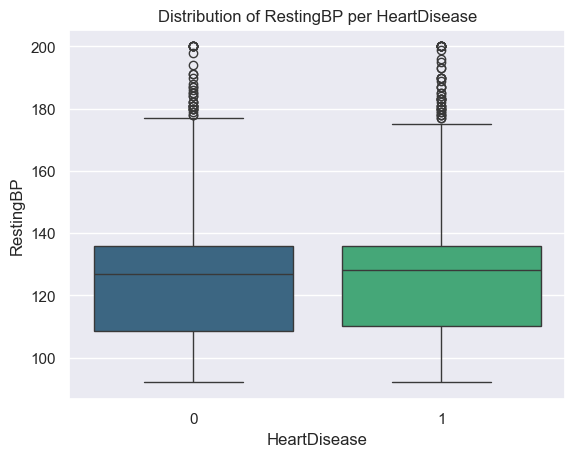

--------------------------------------------------
Distribution of Cholesterol per 'HeartDisease' (SYNTHETIC)
               count        mean         std  min    25%    50%    75%    max
HeartDisease                                                                 
0             4387.0  287.069068   99.766392  0.0  247.0  310.0  351.0  603.0
1             5613.0  283.564226  100.491676  0.0  246.0  306.0  349.0  603.0

Statistical tests:
Shapiro test per Cholesterol (target = 0) ShapiroResult(statistic=np.float64(0.9050168955218327), pvalue=np.float64(4.656066430548375e-46))
Shapirot test per Cholesterol (target = 1) ShapiroResult(statistic=np.float64(0.8980657398940425), pvalue=np.float64(1.2352697924418457e-51))

Mann-Whitney U Test:
U-statistic: 12560093.5000, p-value: 8.3447e-02

P-value T-test
0.08229272233094337


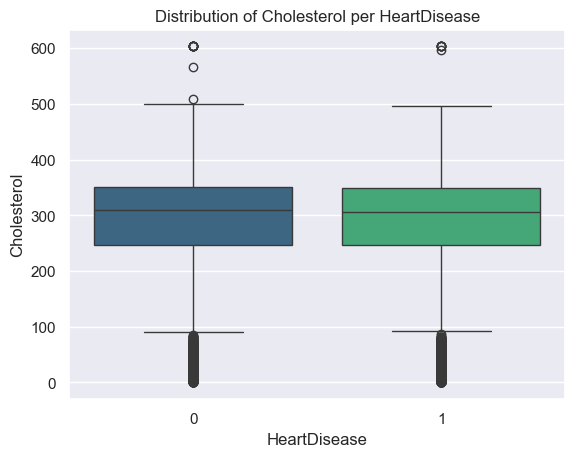

--------------------------------------------------
Distribution of MaxHR per 'HeartDisease' (SYNTHETIC)
               count        mean        std   min   25%    50%    75%    max
HeartDisease                                                                
0             4387.0  111.091862  32.050426  63.0  85.0  109.0  134.0  192.0
1             5613.0  110.814538  31.341109  63.0  86.0  110.0  134.0  192.0

Statistical tests:
Shapiro test per MaxHR (target = 0) ShapiroResult(statistic=np.float64(0.968810861237515), pvalue=np.float64(7.449689948740327e-30))
Shapirot test per MaxHR (target = 1) ShapiroResult(statistic=np.float64(0.970509036082951), pvalue=np.float64(1.8105708066666758e-32))

Mann-Whitney U Test:
U-statistic: 12328701.5000, p-value: 9.0781e-01

P-value T-test
0.6646200201603826


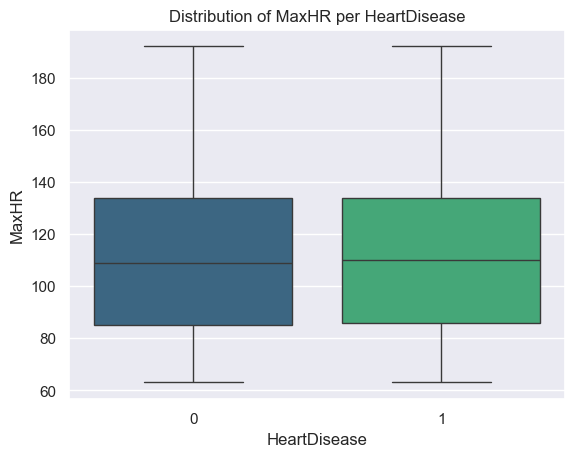

--------------------------------------------------
Distribution of Oldpeak per 'HeartDisease' (SYNTHETIC)
               count      mean       std  min  25%  50%  75%  max
HeartDisease                                                     
0             4387.0  1.296102  1.502016 -1.1  0.2  0.3  2.5  5.6
1             5613.0  1.378799  1.549638 -2.6  0.2  0.3  2.6  5.6

Statistical tests:
Shapiro test per Oldpeak (target = 0) ShapiroResult(statistic=np.float64(0.8121651494450867), pvalue=np.float64(8.718733050042168e-58))
Shapirot test per Oldpeak (target = 1) ShapiroResult(statistic=np.float64(0.8236310118564826), pvalue=np.float64(1.4125721070775846e-61))

Mann-Whitney U Test:
U-statistic: 11872120.5000, p-value: 2.0189e-03

P-value T-test
0.007066028871600651


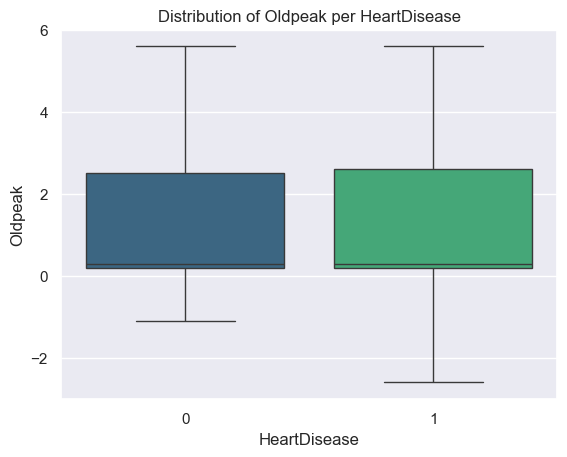

--------------------------------------------------


In [40]:
for col in quantitative_features:
    print(f"Distribution of {col} per 'HeartDisease' (SYNTHETIC)")
    numeric_biv_analysis(syn_df, column=col)
    plt.show()
    print("-"*50)

In this section, we have carried out a bivariate analysis of the various features and the target column; the analysis includes descriptive statistics for the two groups formed based on the target values. We have group 0, where HeartDisease equals 0, and group 1, where HeartDisease equals 1.

The same statistical tests were carried out on both the real and synthetic datasets. The first test performed is the Shapiro test, which statistically demonstrates whether a distribution follows a normal distribution. 

The second test is the Mann-Whitney U test, which is a non-parametric test carried out if the assumption of normality of the distribution is not met; this is why we perform a Shapiro test beforehand.

The third test is the t-test to compare the means between two groups; for this test to be valid, it assumes a normal distribution, so if the Shapiro test demonstrates the normality of the data, we can consider the results of the t-test to be valid; otherwise, we will use the results of the Mann-Whitney test.

**Overall Results** :

For the real-world dataset, we can see – both graphically via box plots and through the tests carried out – that there appears to be a statistically significant difference between the means of the two groups; therefore, these variables potentially contain useful information that machine learning models can capture.

As we had already seen from the univariate analysis, there are several outliers that skew the distribution—values that are physiologically improbable, such as blood pressure readings of 0 or cholesterol levels of 0.

On the other hand, for the synthetic dataset, we have a completely opposite situation: the data generated by the CTGAN do not seem to have captured the statistical relationships between the various numerical features and the target very well; in fact, every statistical test carried out rejects the alternative hypothesis, and therefore the features appear to contain a great deal of noise and offer little informative value.

#### Qualitative Features Vs Target

**Real dataset**

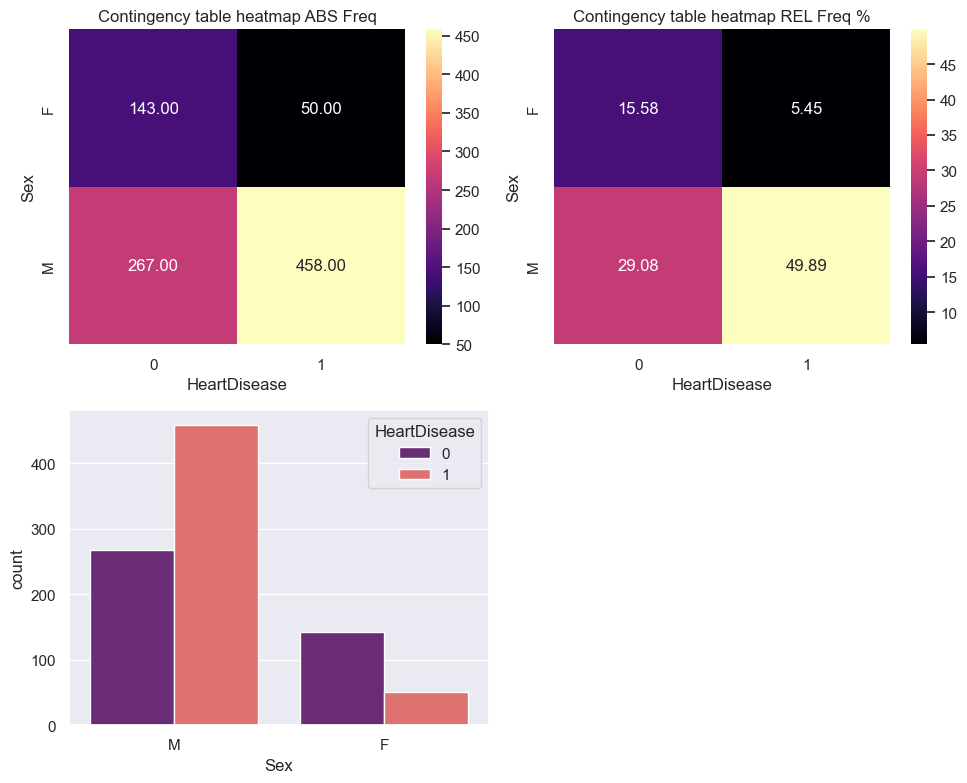

P-value for Chi-Quadro Test: 4.597617450809164e-20
Cramer's V : 0.305


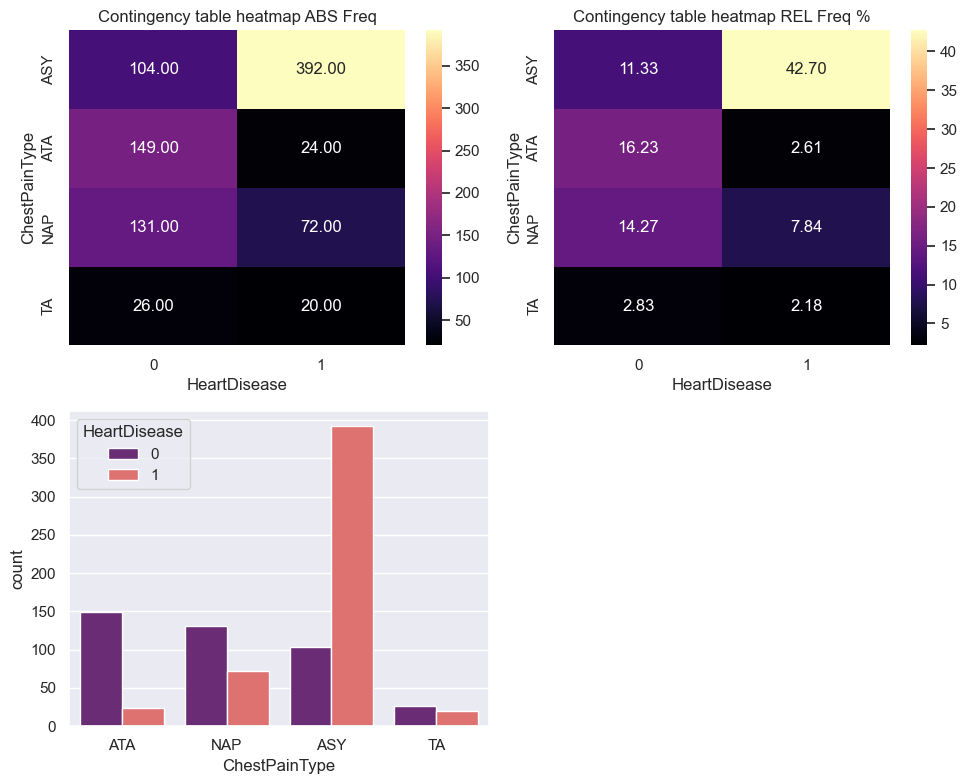

P-value for Chi-Quadro Test: 8.08372842808765e-58
Cramer's V : 0.540


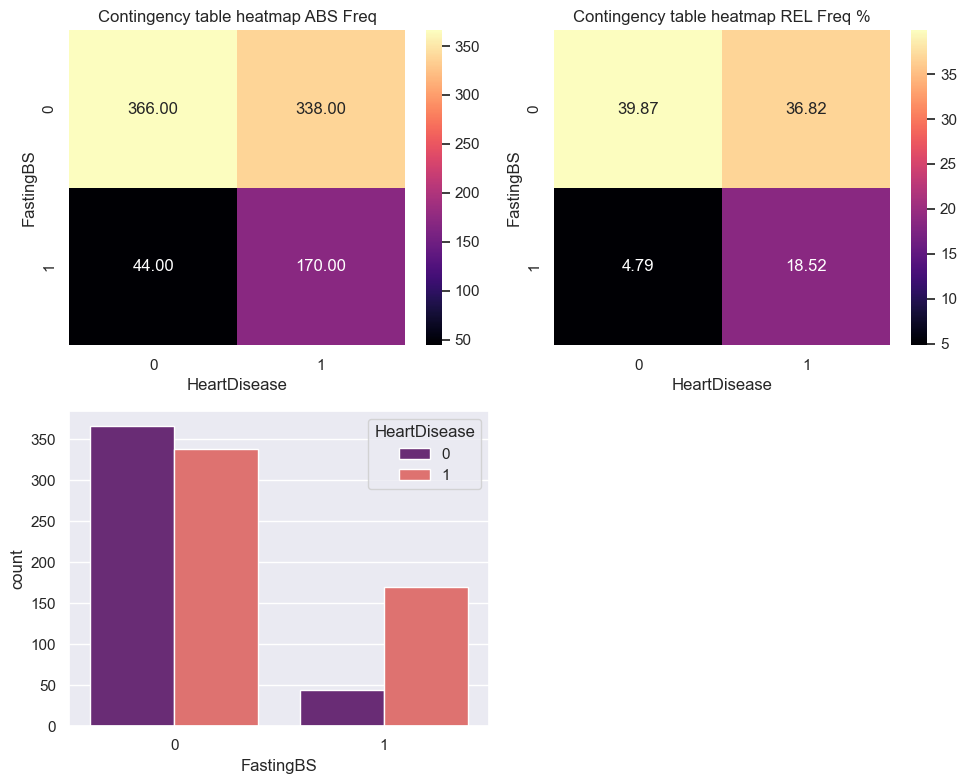

P-value for Chi-Quadro Test: 1.0573018731809955e-15
Cramer's V : 0.267


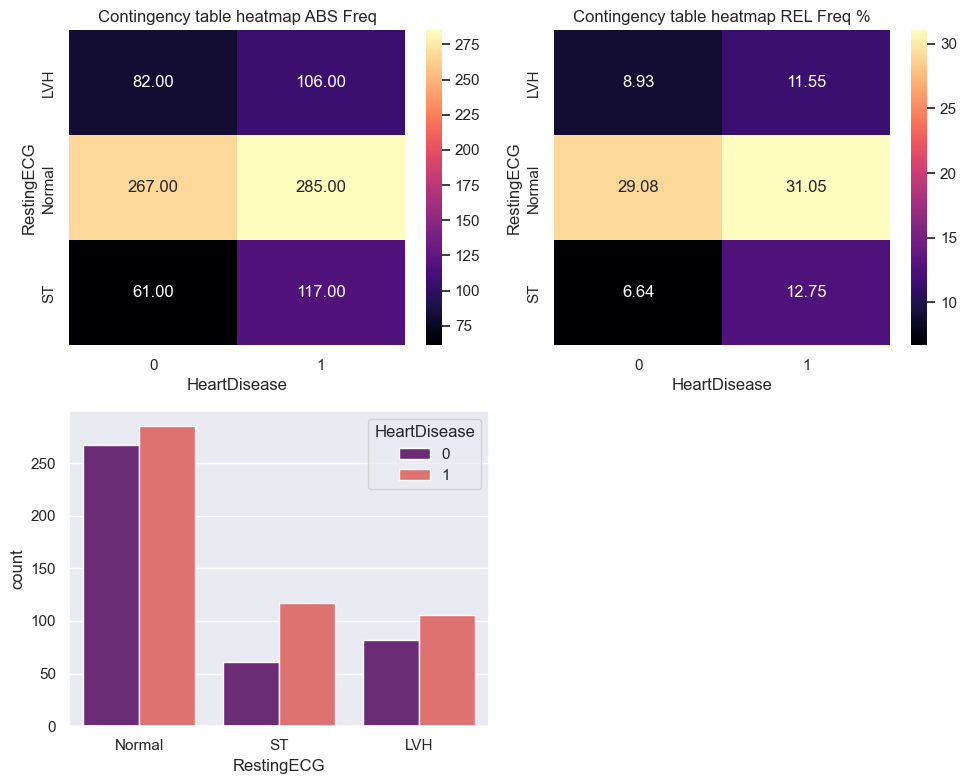

P-value for Chi-Quadro Test: 0.0042292328167544925
Cramer's V : 0.109


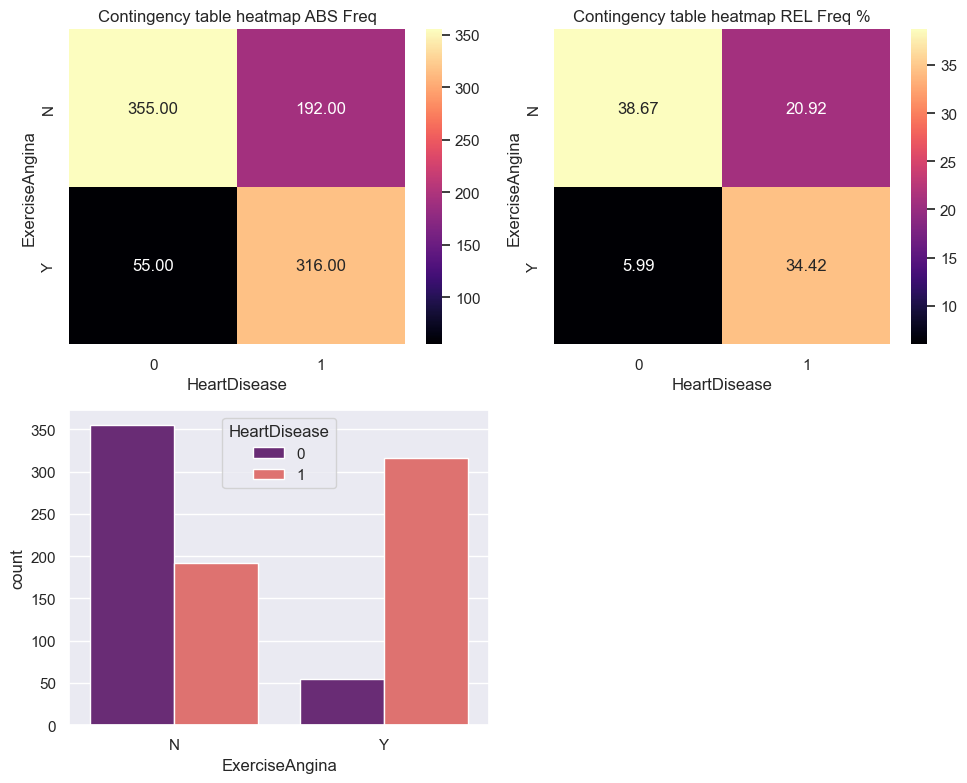

P-value for Chi-Quadro Test: 2.907808387659878e-50
Cramer's V : 0.494


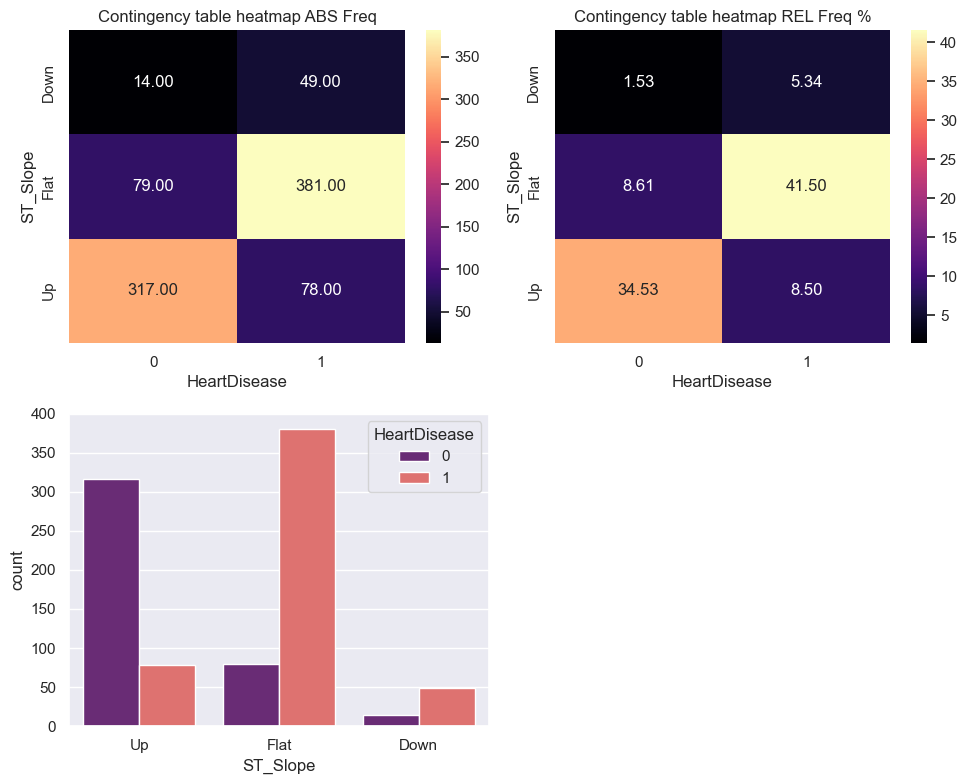

P-value for Chi-Quadro Test: 5.167637689470128e-78
Cramer's V : 0.623


In [41]:
# real
# we remove the target class from the list
for col in qualitative_cols[:-1]:
    qualitative_association(df=df, column=col)
    plt.show()

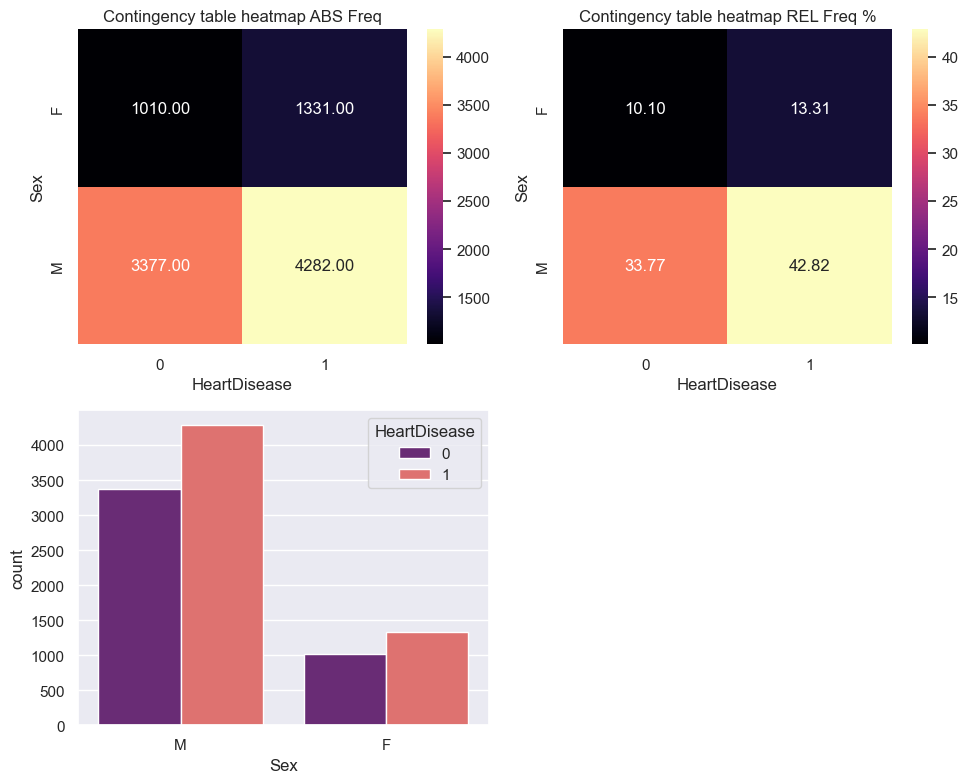

P-value for Chi-Quadro Test: 0.4323906799118583
Cramer's V : 0.008


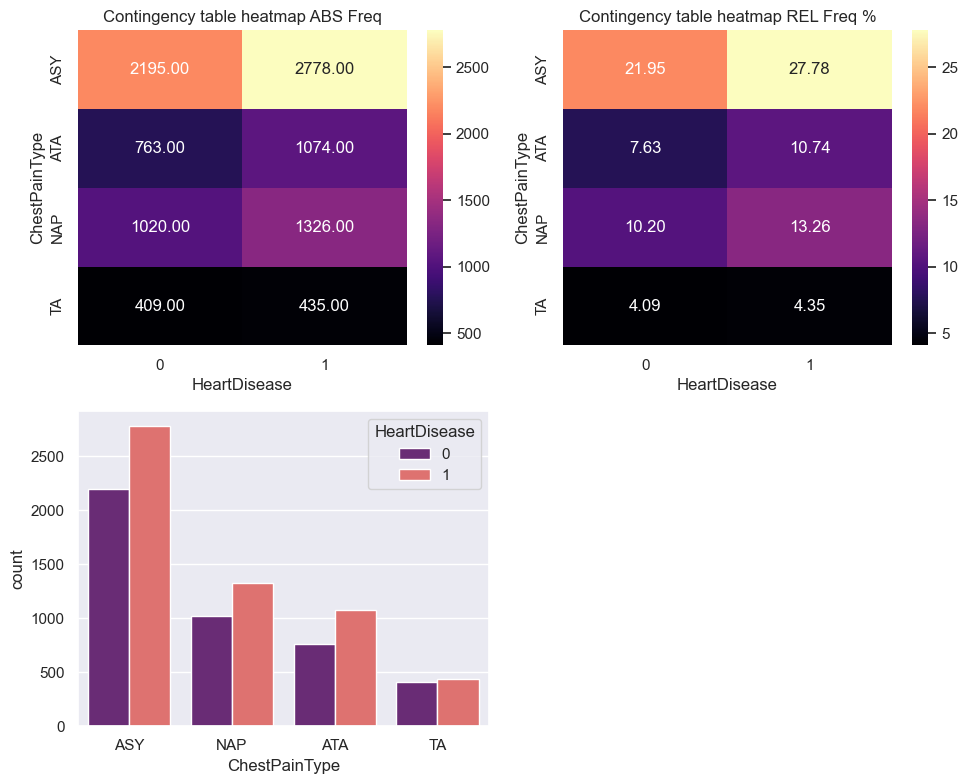

P-value for Chi-Quadro Test: 0.008974065085019507
Cramer's V : 0.034


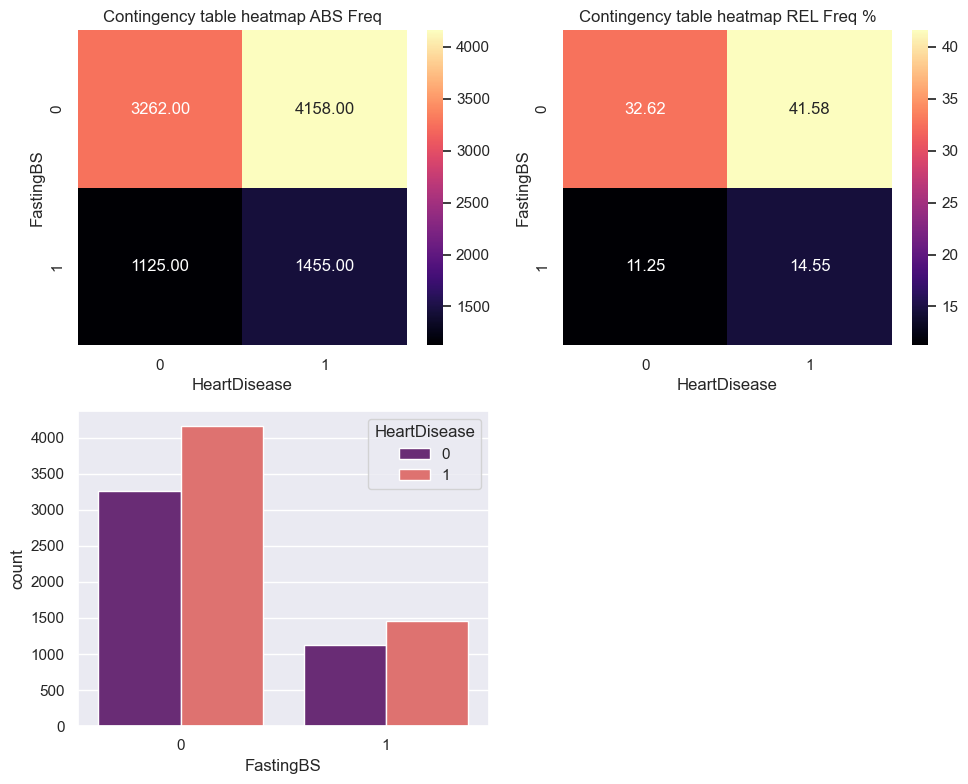

P-value for Chi-Quadro Test: 0.7700685229439787
Cramer's V : 0.003


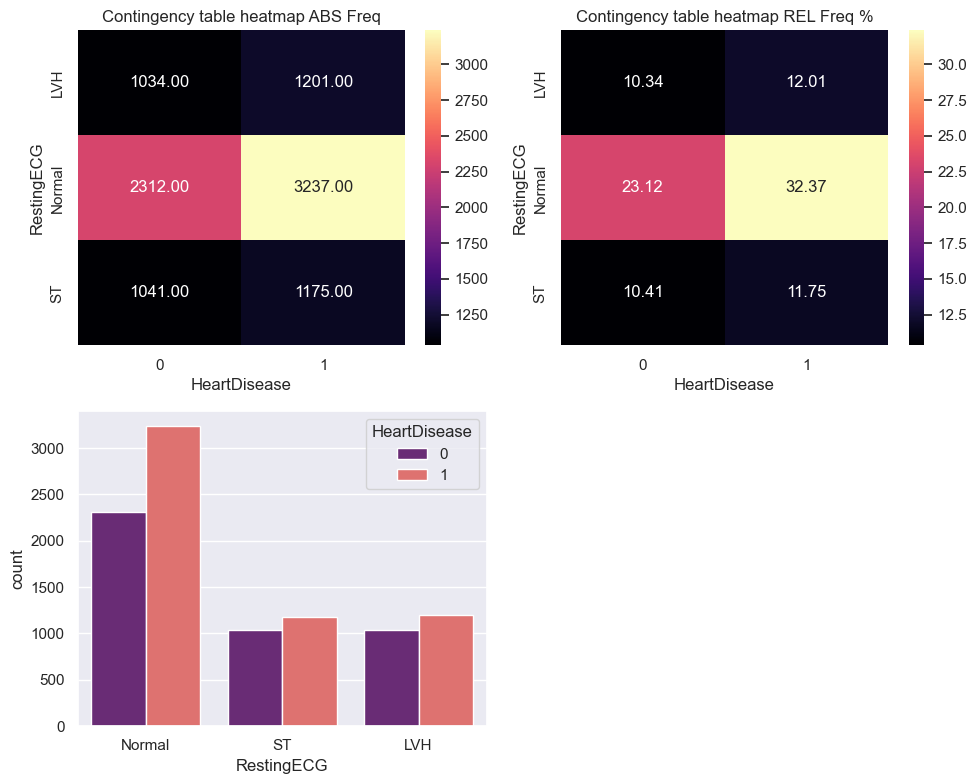

P-value for Chi-Quadro Test: 4.0341643076880276e-06
Cramer's V : 0.050


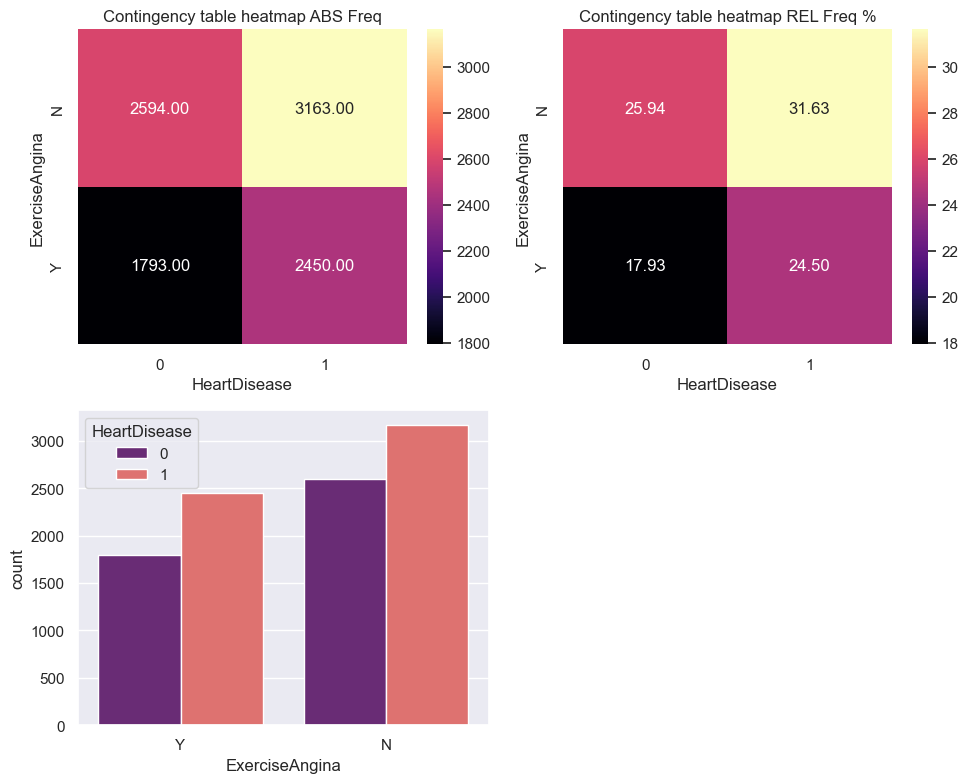

P-value for Chi-Quadro Test: 0.005627588591987841
Cramer's V : 0.028


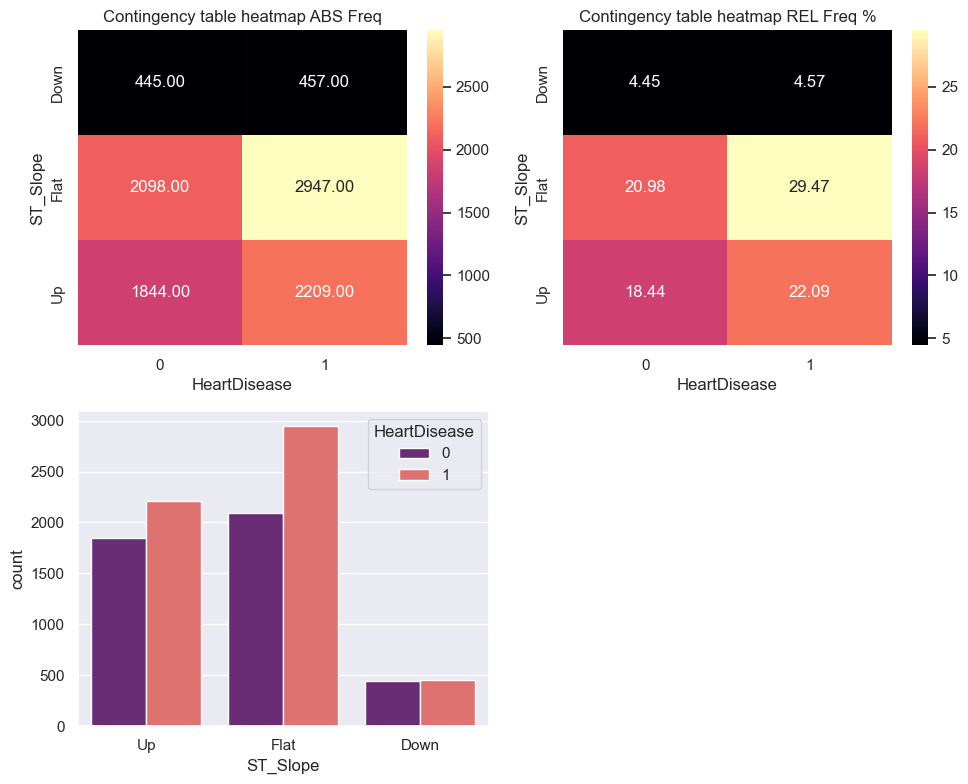

P-value for Chi-Quadro Test: 2.2742684320161028e-06
Cramer's V : 0.051


In [42]:
# synthetic
# we remove the target class from the list
for col in qualitative_cols[:-1]:
    qualitative_association(df=syn_df, column=col)
    plt.show()

In this section, we have instead carried out a bivariate analysis between the categorical features and the target variable, examining the association between the features and the ‘HeartDisease’ column. We will use contingency tables and bar charts to illustrate the differences in frequency distributions for each category of the various columns and for each value of the target class.

As a statistical test to support this analysis, we will use the Chi-square test, which examines the association between two categorical variables; to complement the Chi-square test, we will use Cramer’s V, a statistic that measures the strength of the association between the variables.

**Overall Results**

For the real dataset, we see that all categorical features are associated with the target, albeit with a modest strength of association. In contrast, in the synthetic dataset, we have a situation similar to what we saw with numerical features: the association between categorical features and the target is largely absent, as can also be seen from the p-values, or, if present, is very weak.

These results once again confirm that whilst the CTGAN model has largely succeeded in replicating the original data distribution, it has failed to replicate the internal relationships within the data, thereby producing a great deal of noise and little of the information that is essential for building predictive models.

### Multivariate Analysis

Text(0.5, 1.0, 'Correlation Matrix Real Data')

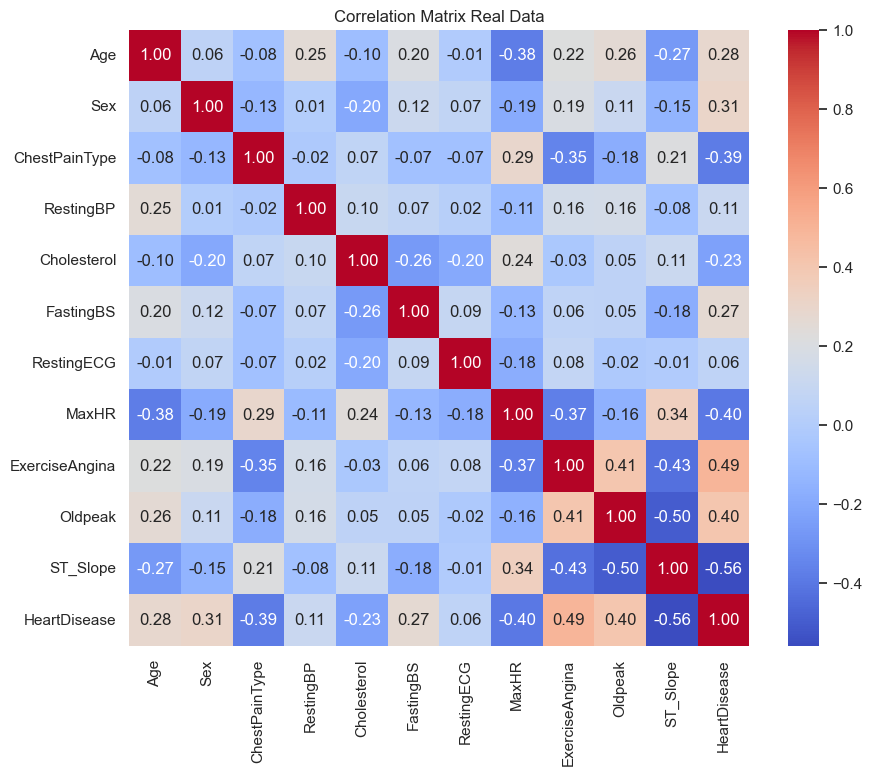

In [43]:
plot_corr_matrix(df=df)
plt.title("Correlation Matrix Real Data")

Text(0.5, 1.0, 'Correlation Matrix Synthetic Data')

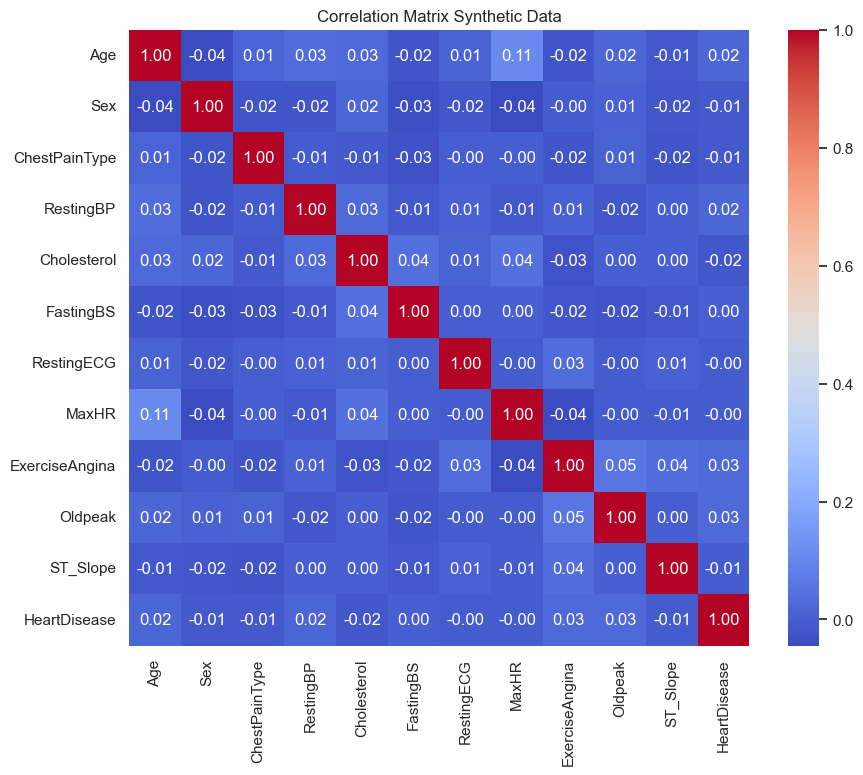

In [44]:
plot_corr_matrix(df=syn_df)
plt.title("Correlation Matrix Synthetic Data")

Using multivariate analysis, we can examine the relationships between features via the correlation matrix, which shows the linear correlations between features.

For the real dataset, we can see that several features have a moderate correlation with the target variable, whilst others have a weaker correlation, such as the RestingBP and RestingECG variables; others, however, show a fairly strong correlation, such as ST_Slope and ExerciseAngina. 

The synthetic dataset, on the other hand, once again demonstrates its inability to capture the relationships in the data, showing correlations of around 0 for almost all variables.

### Evaluation of Synthetic Data Quality

Having examined the distribution of the synthetic data through a comparative analysis with the original dataset, we will now use the tools provided by the SDV library to assess the quality of the synthetic data generated.

In [45]:
diagnostic_report(real_data=df, synthetic_data=syn_df)

Generating report ...

(1/2) Evaluating Data Validity: |          | 0/12 [00:00<?, ?it/s]|

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 1336.90it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 221.49it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [46]:
quality_report(real_data=df, synthetic_data=syn_df)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 62.81it/s]|
Column Shapes Score: 84.16%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 315.06it/s]|
Column Pair Trends Score: 62.1%

Overall Score (Average): 73.13%



AGGIUNGERE SPIEGAZIONE + AGGIUNGERE RISULTATI DI KS TEST E ALTRO CON SDV

##  Model Training and Evaluation

In this section, we will train and test various machine learning models and then evaluate their performance. As we have seen from the comparative analysis, the synthetic dataset does not appear to have captured the underlying relationships in the data; however, as a definitive test of the quality of the synthetic data, we will train a classifier using a complete pipeline for pre-processing and model training, and evaluate the model’s performance on real, previously unseen data.

This approach is known as ‘Train Synthetic, Test Real’ and is the standard method for evaluating the predictive quality of a synthetic dataset. We will subsequently follow the same approach with synthetic datasets generated using a greater number of epochs; at present, the dataset was generated using 300 epochs, which is the default value recommended by SDV for training a CTGAN. It is likely that with only 300 training epochs, the CTGAN model did not achieve convergence, and for this reason failed to capture the relationships in the data.

In [47]:
from sklearn.linear_model import LogisticRegression
from src.models import evaluate_synthetic_quality
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['HeartDisease'])

model = LogisticRegression(random_state=42)

res = evaluate_synthetic_quality(
    model,
    param_grid={},
    syn_df=syn_df,
    train_real_df=train_df,
    test_real_df=test_df,
    num_cols=quantitative_features,
    cat_cols=qualitative_cols[:-1]
)


 Training LogisticRegression model on synthetic data

 Training LogisticRegression model on real data

Model: LogisticRegression
Best params SYNTHETIC: {}
Accuracy TRTR (Real on Real): 0.8587
Accuracy TSTR (Synthetic on Real): 0.5543
Sythetic Data Efficacy: 64.56%
